# Pipeline End-to-End — Multi-Intent Agentic Planning

Notebook chay toan bo pipeline EduBot voi **Multi-Intent Detection**, phan ro **tung node** de kiem soat:

```
1 ContextAnalyzer -> 2 IntentRouter (LLM, multi-intent) -> 3 SessionManager -> 4 ActionPlanner (multi-plan) -> 5 RAG Search -> 6 Handler(s) -> 7 Session Save
```

Ket qua pipeline duoc ghi ra `pipeline_trace.log` dang **JSON** (append mode). File `app.log` giu persistent log.

---
## 0. Setup — Path & Environment

In [2]:
import sys
import os
import time
import json
from pathlib import Path

# Project root
PROJECT_ROOT = Path.cwd().parent.parent
print(f"Project root: {PROJECT_ROOT}")

# Add src to path
for p in [str(PROJECT_ROOT), str(PROJECT_ROOT / 'src')]:
    if p not in sys.path:
        sys.path.insert(0, p)

# Load env
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / '.env')

print(f"API Key: {'SET' if os.getenv('GENAI_API_KEY') else 'NOT SET'}")
print(f"Python: {sys.version.split()[0]}")

Project root: c:\Users\Admin\OneDrive - Hanoi University of Science and Technology\Desktop\DATN
API Key: SET
Python: 3.12.4


---
## 1. Init — CustomSearch + Reranker + Orchestrator

In [3]:
from src.config.config import settings
from src.rag.retrieve_rebuild import CustomSearch
from src.rag.reranker import Reranker
from src.llm.orchestrator import Orchestrator

DATA_DIR = PROJECT_ROOT / 'data'
CHUNKS_PATH = str(DATA_DIR / 'rag_chunks_v2.json')
EMBEDDINGS_PATH = str(DATA_DIR / 'embeddings.npy')

print("=" * 60)
print("[NODE 0] Initializing Components")
print("=" * 60)

# 1a. CustomSearch
t0 = time.time()
searcher = CustomSearch(chunks_path=CHUNKS_PATH, embeddings_path=EMBEDDINGS_PATH)
print(f"  CustomSearch: {searcher.corpus_size} chunks, dim={searcher.embeddings.shape[1]} ({time.time()-t0:.2f}s)")

# 1b. Reranker
reranker = Reranker()
print(f"  Reranker: {settings.RERANKER_MODEL} (lazy load)")

# 1c. Orchestrator
orch = Orchestrator(retriever=searcher, reranker=reranker)
print(f"  Orchestrator: ready")
print(f"  LLM Model: {settings.LLM_MODEL}")
print("=" * 60)

[23:04:09] INFO    | Tokenizing 2348 docs with underthesea...


[NODE 0] Initializing Components
CustomSearch initialized: 2348 docs, vocab=9672, avgdl=137.7
  CustomSearch: 2348 chunks, dim=768 (51.25s)
  Reranker: AITeamVN/Vietnamese_Reranker (lazy load)


[23:05:19] INFO    | ContentSupervisor graph compiled successfully


  Orchestrator: ready
  LLM Model: gemini-2.5-flash-lite


---
## 2. Helpers — JSON Viewer & Query Runner

In [4]:
TRACE_LOG = PROJECT_ROOT / 'logs' / 'pipeline_trace.log'
APP_LOG = PROJECT_ROOT / 'logs' / 'app.log'


def pp(obj, title=""):
    """Pretty-print JSON."""
    if title:
        print(f"\n{'\u2500'*60}")
        print(f"  {title}")
        print(f"{'\u2500'*60}")
    print(json.dumps(obj, indent=2, ensure_ascii=False, default=str))


def parse_step(debug_info: dict, node_name: str) -> dict:
    """Extract a specific node from debug_steps."""
    for s in debug_info.get("steps", []):
        if s.get("node") == node_name:
            return s
    return {}


def parse_all_steps(debug_info: dict, node_name: str) -> list:
    """Extract ALL steps matching a node name."""
    return [s for s in debug_info.get("steps", []) if s.get("node") == node_name]


def run_query(orch_inst, query: str, user_id: str = "test_user",
              ui_book: str = "KNTT") -> dict:
    """
    Run 1 query qua full pipeline.
    Tra ve JSON day du voi tat ca node outputs.
    """
    t0 = time.time()
    chunks = []
    for chunk in orch_inst.ask(query, ui_book=ui_book, user_id=user_id):
        chunks.append(chunk)
    elapsed = time.time() - t0

    response = "".join(chunks)
    debug = orch_inst.last_debug_info or {}

    # Per-node extraction
    ctx_step = parse_step(debug, "ContextAnalyzer")
    intent_step = parse_step(debug, "IntentRouter")
    session_step = parse_step(debug, "SessionManager")
    action_step = parse_step(debug, "ActionPlanner")
    handler_steps = parse_all_steps(debug, "Handler")
    book_step = parse_step(debug, "BookFilter")

    return {
        "meta": {
            "request_id": debug.get("request_id"),
            "user_id": debug.get("user_id"),
            "query": query,
            "ui_book": ui_book,
            "timestamp": debug.get("timestamp"),
            "total_time_s": debug.get("total_time_s", round(elapsed, 2)),
        },
        "pipeline": {
            "1_context_analyzer": {
                "enriched": ctx_step.get("enriched", False),
                "rewrite": ctx_step.get("rewrite"),
            },
            "2_intent_router": {
                "total_intents": intent_step.get("total_intents", 1),
                "intents": intent_step.get("intents", [
                    {
                        "intent": intent_step.get("primary_intent"),
                        "task_type": intent_step.get("task_type"),
                        "topic": intent_step.get("topic"),
                        "is_new_topic": intent_step.get("is_new_topic"),
                        "book": intent_step.get("book"),
                    }
                ]),
                "time_s": intent_step.get("time_s"),
            },
            "3_session_manager": {
                "session_id": session_step.get("session_id"),
                "user_id": session_step.get("user_id"),
                "topic": session_step.get("topic"),
                "intent": session_step.get("intent"),
                "book": session_step.get("book"),
                "total_messages": session_step.get("total_messages"),
                "has_quiz_state": session_step.get("has_quiz_state"),
                "has_slide_state": session_step.get("has_slide_state"),
            },
            "4_action_planner": {
                "total_plans": action_step.get("total_plans", 1),
                "plans": action_step.get("plans", [
                    {
                        "action": action_step.get("action"),
                        "reason": action_step.get("reason"),
                        "round_id": action_step.get("round_id"),
                    }
                ]),
            },
            "5_book_resolution": {
                "effective_book": debug.get("effective_book"),
                "book_filter_status": book_step.get("status", "passed"),
            },
            "6_handlers": handler_steps or [{"status": "no_handler_logged"}],
        },
        "response": {
            "length": len(response),
            "has_separator": "---" in response,
            "num_sections": response.count("---") + 1 if "---" in response else 1,
            "preview": response[:500],
        },
        "raw_debug_steps": debug.get("steps", []),
    }


def show_app_log(n=30):
    """Hien thi n dong cuoi cua app.log."""
    if APP_LOG.exists():
        lines = APP_LOG.read_text(encoding='utf-8').strip().split('\n')
        for line in lines[-n:]:
            print(line)
    else:
        print('[!] app.log chua ton tai')


print('Helpers loaded: pp(), run_query(), parse_step(), show_app_log()')

Helpers loaded: pp(), run_query(), parse_step(), show_app_log()


[07:39:10] INFO    | ContentSupervisor graph compiled successfully


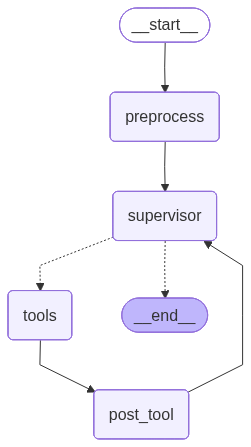

In [6]:
from IPython.display import Image, display
from src.llm.graphs.content_supervisor import build_content_supervisor

graph = build_content_supervisor()

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f'Error: {e}')


In [6]:
# ============================================================
# NODE 1 — E2E TRACE (use existing init: orch/searcher/reranker)
# ============================================================

import time
import json
from collections import Counter

from langgraph.types import Command
from langchain_core.messages import ToolMessage

from src.schemas.context import RequestContext
from src.llm.action_planner import Action
from src.rag.context_combiner import format_contexts

QUERY = "tạo cho tôi slide về chủ đề A bài 1 của bộ sách cánh diều lớp 10"
UI_BOOK = "CD"
USER_ID = f"e2e-{int(time.time())}"

MAX_PRINT_CHUNKS = 20
PRINT_FULL_TOOL_PAYLOAD = False
RECURSION_LIMIT = 20

print("=" * 90)
print("[NODE 1] E2E WORKFLOW TRACE — GENERATE_SLIDE")
print("=" * 90)
print(f"Query: {QUERY}")
print(f"User:  {USER_ID}")
print(f"Book:  {UI_BOOK}")

# 1) Build context
ctx = RequestContext(query=QUERY, ui_book=UI_BOOK, user_id=USER_ID)
ctx.enriched_query = ctx.query
ctx.queries_for_rag = [ctx.query]

# 2) Context analyze + rewrite
print("\n" + "-" * 90)
print("A) Context + Rewrite")
print("-" * 90)

current_session = orch.memory.get_current_session(USER_ID)
history_text = ""
if current_session:
    history_text = "\n".join(f"{m.role}: {m.content}" for m in current_session.messages[-5:])

needs_context = orch.context_analyzer.needs_contextualization(ctx.query, history_text)
print(f"needs_contextualization = {needs_context}")

if needs_context:
    context_snippet = orch.context_analyzer.extract_context_from_history(ctx.query, history_text)
    ctx.enriched_query = f"Ngu canh truoc do:\n{context_snippet}\n\nCau hoi hien tai: {ctx.query}"
    t_rw = time.time()
    rewritten_queries = orch.query_rewriter.rewrite(ctx.query, context_snippet)
    rw_time = time.time() - t_rw
    ctx.queries_for_rag = rewritten_queries if rewritten_queries else [ctx.query]
    print(f"rewrite_needed = True, rewrite_time = {rw_time:.2f}s")
    for i, q in enumerate(ctx.queries_for_rag, 1):
        print(f"  [{i}] {q}")
else:
    print("rewrite_needed = False")

# 3) Intent
print("\n" + "-" * 90)
print("B) Intent Router")
print("-" * 90)

current_topic = current_session.topic if current_session else None
session_messages = current_session.get_context_messages() if current_session else None

t_intent = time.time()
intent_results = orch.intent_router.detect_multi(
    query=ctx.enriched_query,
    current_topic=current_topic,
    session_messages=session_messages,
)
intent_time = time.time() - t_intent

ctx.intent_results = intent_results
ctx.intent_result = intent_results[0] if intent_results else None

print(f"intent_time = {intent_time:.2f}s, count = {len(intent_results)}")
for i, it in enumerate(intent_results, 1):
    print(
        f"  [{i}] intent={it.primary_intent}, task_type={it.task_type}, "
        f"topic={it.topic}, is_new_topic={it.is_new_topic}, book={it.book}"
    )

# 4) Session + Plan
print("\n" + "-" * 90)
print("C) Session + Action Plan")
print("-" * 90)

ctx.session = orch.session_manager.resolve_session(ctx.intent_result, user_id=ctx.user_id)
ctx.session.add_message("user", ctx.query)

action_plans = orch.action_planner.plan_all(ctx.intent_results, ctx.session, ctx.query)
ctx.action_plans = action_plans
ctx.action_plan = action_plans[0] if action_plans else None

print(f"session_id={ctx.session.session_id}, msgs={len(ctx.session.messages)}")
for i, p in enumerate(action_plans, 1):
    print(f"  [{i}] action={p.action.value}, reason={p.reason}")

slide_plan = next((p for p in action_plans if p.action == Action.GENERATE_SLIDE), None)
if not slide_plan:
    raise RuntimeError("No GENERATE_SLIDE plan. Đổi query để test slide.")

# 5) Book resolve
ctx.resolve_book()
print(f"effective_book={ctx.effective_book}")
if not ctx.effective_book:
    raise RuntimeError("Missing effective_book for slide generation.")

# 6) RAG retrieve + combine
print("\n" + "-" * 90)
print("D) RAG Retrieval")
print("-" * 90)

t_rag = time.time()
chunks = orch.rag_service.get_context(ctx, intent_hint="generate", task_type="slide")
rag_time = time.time() - t_rag

print(f"rag_time = {rag_time:.2f}s, chunks={len(chunks)}")
if not chunks:
    raise RuntimeError("RAG returned 0 chunks.")

for i, c in enumerate(chunks[:MAX_PRINT_CHUNKS], 1):
    meta = c.get("metadata", {})
    score = c.get("score")
    score_text = f"{score:.4f}" if isinstance(score, (int, float)) else str(score)
    preview = (c.get("content", "") or "").replace("\n", " ")
    preview = preview[:160] + ("..." if len(preview) > 160 else "")
    print(
        f"  [{i:02d}] score={score_text} | grade={meta.get('grade')} | "
        f"book={meta.get('book')} | topic={meta.get('topic_name')} | lesson={meta.get('lesson_name')}"
    )
    print(f"       {preview}")

combined_context = format_contexts(chunks, action="generate_slide")
print(f"\ncombined_context_chars={len(combined_context)}")
print(combined_context[:800] + ("..." if len(combined_context) > 800 else ""))

# 7) Graph execute (auto HITL resume)
print("\n" + "-" * 90)
print("E) Graph Supervisor / Tools / HITL(auto)")
print("-" * 90)

graph = orch.slide_service.graph
thread_id = f"e2e-slide-{int(time.time())}"

initial_state = {
    "task_type": "slide",
    "request_id": ctx.request_id,
    "query": ctx.enriched_query,
    "topic": (ctx.intent_result.topic if ctx.intent_result else None) or "Bài học",
    "grade": orch.rag_service._extract_grade_from_topic(
        (ctx.intent_result.topic if ctx.intent_result else QUERY)),
    "book": ctx.effective_book,
    "rag_chunks": chunks,
    "messages": [],
    "context_map": "",
    "chunk_map": {},
    "outline_payload": None,
    "content_payload": None,
    "media_payload": None,
    "quiz_payload": None,
    "merged_slides": None,
    "final_output": None,
    "status": "pending",
    "error_message": None,
}

config = {
    "configurable": {"thread_id": thread_id},
    "recursion_limit": RECURSION_LIMIT,
}

tool_payloads = {}
tool_calls_trace = []
interrupt_count = 0
step = 0

def pp(obj):
    return json.dumps(obj, indent=2, ensure_ascii=False)

def run_stream(stream_input):
    global step, interrupt_count
    for chunk in graph.stream(stream_input, config=config, stream_mode="updates"):
        if "__interrupt__" in chunk:
            interrupt_count += 1
            print(f"\n[INTERRUPT #{interrupt_count}]")
            for intr in chunk["__interrupt__"]:
                val = intr.value if hasattr(intr, "value") else intr
                print(pp(val) if isinstance(val, dict) else str(val))
            return "interrupt"

        for node_name, output in chunk.items():
            if node_name.startswith("__"):
                continue
            step += 1
            print(f"\n[STEP {step:02d}] node={node_name}")

            if node_name == "preprocess":
                print(f"  context_map_chars={len(output.get('context_map',''))}, chunk_map={len(output.get('chunk_map',{}))}")

            elif node_name == "supervisor":
                msgs = output.get("messages", [])
                for msg in msgs:
                    if hasattr(msg, "tool_calls") and msg.tool_calls:
                        for tc in msg.tool_calls:
                            tool_calls_trace.append(tc["name"])
                            print(f"  supervisor -> {tc['name']} args={pp(tc.get('args', {}))}")
                    elif hasattr(msg, "content") and msg.content:
                        print(f"  final_text: {str(msg.content)[:400]}")

            elif node_name == "tools":
                for msg in output.get("messages", []):
                    if isinstance(msg, ToolMessage):
                        tname = getattr(msg, "name", "unknown")
                        try:
                            parsed = json.loads(msg.content)
                            tool_payloads[tname] = parsed
                            if PRINT_FULL_TOOL_PAYLOAD:
                                print(f"  tool={tname}\n{pp(parsed)}")
                            else:
                                print(f"  tool={tname}, keys={list(parsed.keys())}")
                        except Exception:
                            print(f"  tool={tname}, raw={str(msg.content)[:300]}")

            elif node_name == "post_tool":
                print(f"  post_tool updates={list(output.keys()) if isinstance(output, dict) else output}")

    return "done"

t_exec = time.time()
status = run_stream(initial_state)
while status == "interrupt":
    print("\n[AUTO RESUME] Command(resume=True)")
    status = run_stream(Command(resume=True))
exec_time = time.time() - t_exec

# 8) Merge report
print("\n" + "-" * 90)
print("F) Final Report (merge/quality)")
print("-" * 90)

print(f"execution_time={exec_time:.2f}s")
print(f"interrupts={interrupt_count}")
print(f"tool_sequence={tool_calls_trace}")

merge_payload = tool_payloads.get("merge_results")
quality_payload = tool_payloads.get("check_quality")

print(f"outline={'OK' if 'generate_outline' in tool_payloads else 'MISSING'}")
print(f"content={'OK' if 'generate_content' in tool_payloads else 'MISSING'}")
print(f"media={'OK' if 'generate_media' in tool_payloads else 'OPTIONAL/MISSING'}")
print(f"quiz={'OK' if 'generate_quiz' in tool_payloads else 'OPTIONAL/MISSING'}")
print(f"merge={'OK' if merge_payload else 'MISSING'}")
print(f"quality={'OK' if quality_payload else 'MISSING'}")

if merge_payload:
    slides = merge_payload.get("slides", [])
    dist = Counter([s.get("slide_type", "unknown") for s in slides if isinstance(s, dict)])
    print(f"\nmerged_total={merge_payload.get('total', len(slides))}")
    print(f"slide_type_distribution={dict(dist)}")
    for s in slides[:3]:
        print(
            f"  - {s.get('slide_id')} [{s.get('slide_type')}] {s.get('title')} "
            f"(bullets={len(s.get('bullets', []))}, questions={len(s.get('questions', [])) if isinstance(s.get('questions'), list) else 0})"
        )

if quality_payload:
    print(f"\nquality_passed={quality_payload.get('passed')}")
    print(f"quality_auto_fixed={quality_payload.get('auto_fixed')}")
    print(f"quality_issues={quality_payload.get('issues')}")

print("\n" + "=" * 90)
print("DONE")
print("=" * 90)

[NODE 1] E2E WORKFLOW TRACE — GENERATE_SLIDE
Query: tạo cho tôi slide về chủ đề A bài 1 của bộ sách cánh diều lớp 10
User:  e2e-1776701170
Book:  CD

------------------------------------------------------------------------------------------
A) Context + Rewrite
------------------------------------------------------------------------------------------
needs_contextualization = False
rewrite_needed = False

------------------------------------------------------------------------------------------
B) Intent Router
------------------------------------------------------------------------------------------


[23:06:11] INFO    | IntentRouter: 1 intent(s) detected — generate(slide)
[23:06:11] INFO    | No current session, creating new
[23:06:11] INFO    | New session created: id=db58be63, topic='Chủ đề A - Bài 1', intent=generate, book=CD
[23:06:11] INFO    | RAGAgent: book filter='CD' → 1204 chunks in scope
[23:06:11] INFO    | RAGAgent: strategy=hierarchical | grade=10 | topic=Chủ đề A - Bài 1 | book=CD | Query cụ thể + context (grade=10, topic=True) → HRAG
[23:06:11] INFO    | HRAG Phase 1: 242 parents searched → 3 selected → 3 unique lessons
[23:06:11] INFO    | HRAG Phase 2: scoped search on 24 child chunks


intent_time = 1.35s, count = 1
  [1] intent=generate, task_type=slide, topic=Chủ đề A - Bài 1, is_new_topic=True, book=CD

------------------------------------------------------------------------------------------
C) Session + Action Plan
------------------------------------------------------------------------------------------
session_id=db58be63, msgs=1
  [1] action=generate_slide, reason=task_type=slide
effective_book=CD

------------------------------------------------------------------------------------------
D) RAG Retrieval
------------------------------------------------------------------------------------------


[23:06:16] INFO    | RAGAgent done: 5 chunks, 5.34s
[23:06:16] INFO    | ContextCombiner: grouped mode | 1 topics, 5 chunks
[23:06:16] INFO    | Preprocess: 5 chunks → 5 chunk_ids


rag_time = 5.34s, chunks=5
  [01] score=0.0295 | grade=10 | book=CD | topic=Ứng dụng Tin học – ICT: Phần mềm thiết kế đồ họa | lesson=MỘT SỐ KĨ THUẬT THIẾT KẾ SỬ DỤNG VÙNG CHỌN, ĐƯỜNG DẪN VÀ CÁC LỚP ẢNH
       Với kĩ thuật tạo đường viền, dấu chữ thập có thể được bao quanh bởi một đường tròn. Thực hiện các bước sau đây để tạo một đường viền.  *   Bước 1. Thêm một lớp ...
  [02] score=0.0304 | grade=10 | book=CD | topic=Ứng dụng Tin học – ICT: Phần mềm thiết kế đồ họa | lesson=THỰC HÀNH TỔNG HỢP
       * Thêm lớp mới để tạo nền banner. Nền banner được tạo bằng vùng chọn hình chữ nhật và được tô màu gradient với các thuộc tính gradient: FG/BG = Đen/Trắng, gradi...
  [03] score=0.0295 | grade=10 | book=CD | topic=Ứng dụng Tin học – ICT: Phần mềm thiết kế đồ họa | lesson=THỰC HÀNH TỔNG HỢP
       * Thêm lớp **Tam giác** bên trên lớp **Màu nền** để chứa hoạ tiết tam giác màu đen. Hoạ tiết này bắt đầu được tạo bằng một vùng chọn hình vuông, được tô màu đen...
  [04] score=0.0264 | grade=10 |

...


[STEP 06] node=tools
  tool=generate_content, keys=['slides']

[STEP 07] node=post_tool
  post_tool updates=['content_payload', 'outline_payload']


[23:06:54] INFO    | Merged: 8 slides, content=7, media=no, quiz=0
[23:06:54] INFO    | Merged: 8 slides
[23:06:54] INFO    | Post-tool: stored ['merged_slides', 'content_payload', 'outline_payload'] in state



[STEP 08] node=supervisor
  supervisor -> merge_results args={}

[STEP 09] node=tools
  tool=merge_results, keys=['slides', 'total', 'status']

[STEP 10] node=post_tool
  post_tool updates=['merged_slides', 'content_payload', 'outline_payload']


[23:06:56] WARNING | Quality gate: 1 issues — ["GROUNDING: Slides thiếu source_chunk_ids: ['s1']"]
[23:06:56] WARNING | Quality gate failed: ["GROUNDING: Slides thiếu source_chunk_ids: ['s1']"]
[23:06:56] WARNING | Quality gate: 1 issues — ["GROUNDING: Slides thiếu source_chunk_ids: ['s1']"]
[23:06:56] INFO    | Post-tool: stored ['merged_slides', 'content_payload', 'outline_payload'] in state



[STEP 11] node=supervisor
  supervisor -> check_quality args={}

[STEP 12] node=tools
  tool=check_quality, keys=['passed', 'auto_fixed', 'issues', 'slides']

[STEP 13] node=post_tool
  post_tool updates=['merged_slides', 'content_payload', 'outline_payload']

[STEP 14] node=supervisor
  final_text: Đã tạo xong 8 slides cho bài Chủ đề A - Bài 1.

------------------------------------------------------------------------------------------
F) Final Report (merge/quality)
------------------------------------------------------------------------------------------
execution_time=45.50s
interrupts=1
tool_sequence=['generate_outline', 'generate_content', 'merge_results', 'check_quality']
outline=OK
content=OK
media=OPTIONAL/MISSING
quiz=OPTIONAL/MISSING
merge=OK
quality=OK

merged_total=8
slide_type_distribution={'title': 1, 'content': 5, 'exercise': 1, 'summary': 1}
  - s1 [title] Một số kĩ thuật thiết kế sử dụng vùng chọn, đường dẫn và các lớp ảnh (bullets=6, questions=0)
  - s2 [content] Kĩ 